# Boilerplate - Loading raw data and filtering for English only

In [29]:
import pandas as pd

notes = pd.read_csv('~/Desktop/Community Notes/original files from x/notes-00000.tsv', sep='\t') # data downloaded from X on 11/14/24
status_history = pd.read_csv('~/Desktop/Community Notes/original files from x/noteStatusHistory-00000.tsv', sep='\t')

notes = notes.astype(str)
status_history = status_history.astype(str)

notesandstatus = notes.merge(status_history, on='noteId', how='outer')

columns_to_keep = [
    "noteId",
    "noteAuthorParticipantId_x",
    "createdAtMillis_x",
    "tweetId",
    "classification",
    "summary",
    "timestampMillisOfFirstNonNMRStatus",
    "firstNonNMRStatus"
    
]

notesandstatus = notesandstatus[columns_to_keep]

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_50755/815401376.py:3: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  notes = pd.read_csv('~/Desktop/Community Notes/original files from x/notes-00000.tsv', sep='\t') # data downloaded from X on 11/14/24
/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_50755/815401376.py:4: DtypeWarning: Columns (10,19) have mixed types. Specify dtype option on import or set low_memory=False.
  status_history = pd.read_csv('~/Desktop/Community Notes/original files from x/noteStatusHistory-00000.tsv', sep='\t')


In [ ]:
%pip install langdetect

In [483]:
# *this cell takes about 45 minutes to run*

notesandstatus['has_summary'] = notesandstatus['summary'].notna() & notesandstatus['summary'].str.strip().ne("")
notesandstatus['summary'] = notesandstatus['summary'].astype(str)

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 0

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False 

notesandstatus['is_english'] = notesandstatus['summary'].apply(is_english)

# saving 'notesandstatus.csv' here, so I can read in this basic version of my data w/o needing to rerun spanish filter.
notesandstatus.to_csv('~/Desktop/Community Notes/community_notes_data/notesandstatus.csv', index=False)

In [7]:
# Read in fresh df; create new columns in df ('got_shown', 'hours_to_show', 'is_followedup').

import numpy as np
import pandas as pd

notesandstatus = pd.read_csv('~/Desktop/Community Notes/community_notes_data/notesandstatus.csv', dtype={'tweetId': str})

df = notesandstatus

df['firstNonNMRStatus'] = df['firstNonNMRStatus'].replace('nan', np.nan)
df['is_followedup'] = df['firstNonNMRStatus'].notna()

df['got_shown'] = (df['firstNonNMRStatus'] == 'CURRENTLY_RATED_HELPFUL').astype(int)

df['time_difference'] = None

df['timestampMillisOfFirstNonNMRStatus'] = df['timestampMillisOfFirstNonNMRStatus'].replace('nan', np.nan)

df['timestampMillisOfFirstNonNMRStatus'] = df['timestampMillisOfFirstNonNMRStatus'].astype(float).astype('Int64')

df['createdAtMillis_x'] = df['createdAtMillis_x'].replace('nan', np.nan)

df['createdAtMillis_x'] = df['createdAtMillis_x'].astype(float).astype('Int64')

for index, row in df.iterrows():
    if row['got_shown'] == 1:
        df.at[index, 'time_difference'] = row['timestampMillisOfFirstNonNMRStatus'] - row['createdAtMillis_x']

df['hours_to_show'] = df['time_difference'] / (1000 * 60 * 60)

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_13560/1965582423.py:6: DtypeWarning: Columns (1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  notesandstatus = pd.read_csv('~/Desktop/Community Notes/community_notes_data/notesandstatus.csv', dtype={'tweetId': str})


In [8]:
# Looping through each ratings file to pull together all of the note ratings for each note. takes about 10 minutes to run:
import pandas as pd
import glob
import os

ratings_dir = os.path.expanduser("~/Desktop/Community Notes/original files from x/ratings/")

all_ratings = pd.DataFrame()

for file in glob.glob(os.path.join(ratings_dir, "ratings-*.tsv")):
    df_file = pd.read_csv(file, sep='\t')
    
    all_ratings = pd.concat([all_ratings, df_file], ignore_index=True)

all_ratings.to_csv("all_ratings.csv", index=False)

# Analysis: Comparing got_shown means and # of ratings for different keyword lists

In [184]:
# Function takes a list of keywords (ie. "scam_keywords" and a keyword_name such as "scam"), 
# and creates a new column in df (ie. is_scam). Also updates df_english to include new is__ column.

import re

def add_keyword_column(df, keywords, keyword_name):
    def contains_keywords(text, keywords):
        text_lower = str(text).lower()
        return any(re.search(rf'\b{re.escape(keyword.lower())}\b', text_lower) for keyword in keywords)

    df[f'is_{keyword_name}'] = df['summary'].apply(lambda text: contains_keywords(text, keywords))
    tweet_ids = set(df[df[f'is_{keyword_name}']]['tweetId'])
    df[f'is_{keyword_name}'] |= df['tweetId'].isin(tweet_ids)

# keywords were collected in the following ways: my own ideas, gpt suggestions, gpt grouping of top words and bigrams from 'summary' corpus:
political_keywords = [
    "5G", "activist", "amendment", "anti-corruption", "anti-vax", "assembly", "autocracy",
    "authoritarian", "ballot", "biden", "campaign", "candidate", "capitalist", "caucus",
    "censorship", "city council", "civic", "civil liberties", "climate policy", "clinton",
    "congress", "congressman", "congresswoman", "conservative", "constitution", "conspiracy",
    "corruption", "council", "covid", "court", "debate", "democracy", "democrat", "disinformation",
    "diplomacy", "election", "elon musk", "equality", "european union", "executive", "federal",
    "foreign", "freedom", "gaza", "government", "governor", "hamas", "harris", "healthcare",
    "hezbollah", "hoax", "house of representatives", "immigration", "infrastructure", "iran",
    "israel", "israeli", "joe biden", "judiciary", "justice", "kamala harris", "kim jong un",
    "law", "left-wing", "legislation", "liberal", "lobbyist", "mandate", "mayor", "mcconnell",
    "middle east", "military", "misinformation", "movement", "mp", "musk", "nation",
    "national", "national security", "nationalism", "nato", "netanyahu", "news politics",
    "news world", "obama", "pac", "palestinian", "parliament", "party", "patriot", "patriotism",
    "pelosi", "plandemic", "policies", "policy", "political", "politics", "polling", "poverty",
    "power", "president", "progressive", "public office", "putin", "rally", "reform",
    "regulation", "relations", "representative", "republican", "rights", "russia", "sanctions",
    "schumer", "senate", "senator", "socialism", "socialist", "sovereignty", "starmer", "state",
    "states", "stimulus", "supreme court", "surveillance", "tariffs", "taxes", "transparency",
    "trump", "ukraine", "un", "united states", "vance", "veto", "vote", "walz", "waltz",
    "war", "welfare", "white house", "xi jinping", "zelensky"
]

scam_keywords = [
    "account impersonating", "account takeover", "aware risk", "Bitcoin scam", "blockchain fraud", "Cash App scam",
    "charity scam", "check fraud", "con", "counterfeit unfit", "credit card scam", 
    "crypto scam", "cryptocurrency scam", "debit card fraud", "deceptive", "deceptive site", "detector antivirus",
    "Ethereum scam", "ethereum phishing", "fake account", "fake fundraiser", 
    "fake job", "fake versions", "financial scam", "fishing", "fool people", "fraud", 
    "fraudulent", "get rich quick", "grift", "hoax", "identity theft", "impersonation", 
    "impersonating", "inheritance scam", "investment scam", "io scam", "IRS scam", 
    "job scam", "legal safety", "loan scam", "lottery scam", "malicious transactions", 
    "may counterfeit", "money laundering", "NFT scam", "payPal scam", "personal information",
    "phishing", "Ponzi", "potential threats", "pyramid scheme", "real account", 
    "recovery phrase", "risk products", "rug pull", "scam", "scams", 
    "scheme", "secret recovery", "spoofing", "stimulus check fraud", "stolen assets", 
    "swindle", "tax fraud", "theft malicious", "trading fraud", "transactions resulting", 
    "unfit use", "Venmo scam", "verified scam", "wire fraud", "work from home scam", 
    "Zelle scam"
]

crypto_keywords = ["crypto", "cryptocurrency", "ethereum", "metamask", "blockchain", 
                   "bitcoin", "digital currency", "web3", "decentralized", "nft", "token", 
                   "wallet", "crypto wallet", "crypto exchange", "smart contracts"]

health_keywords = [
    "ADHD", "AIDS", "CDC", "FDA", "HIV", "ICU", "NIH", "PTSD", "WHO", "acute", "adverse events",
    "allergy", "anxiety", "antibiotic", "antiviral", "asthma", "autism", "autoimmune", "bioweapon",
    "booster", "cancer", "cdc", "chronic", "clinic", "clinical", "clinical trial", "cold",
    "condition", "coronavirus", "covid", "covid vaccine", "covid vaccines", "data", "death",
    "depression", "diagnosis", "disease", "doctor", "double-blind", "drug", "efficacy", 
    "emergency room", "epidemic", "experiment", "fake cure", "flu", "health", "healthcare", 
    "heart disease", "hospital", "hydroxychloroquine", "illness", "influenza", "insulin", 
    "jab", "long covid", "medical", "medication", "medicine", "mental health", "microchip",
    "mRNA", "ncbi", "nih", "nlm", "nurse", "obesity", "outbreak", "pandemic", "patient", 
    "peer-reviewed", "placebo", "pmc", "public health", "research", "safety compliance", 
    "scientific", "side effects", "stroke", "study", "symptom", "treatment", "vaccine", 
    "vaccinated", "vaccination", "vaccines", "wellness"
]

science_keywords = [
    "science", "scientific", "scientist", "research", "study", "studies", "data",
    "evidence", "experiment", "experiments", "theory", "hypothesis", "peer-reviewed",
    "replication", "analysis", "results", "findings", "conclusion", "method", "methodology",
    "biology", "chemistry", "physics", "astronomy", "geology", "ecology", "genetics",
    "evolution", "neuroscience", "psychology", "sociology", "anthropology", "archaeology",
    "mathematics", "statistics", "climate science", "meteorology", "environmental science",
    "computer science", "engineering", "robotics", "artificial intelligence",
    "controlled trial", "clinical trial", "double-blind", "placebo", "observational",
    "correlation", "causation", "sample size", "significant", "statistically significant",
    "margin of error", "confidence interval", "bias", "variance", "model", "simulation",
    "journal", "publication", "preprint", "open access", "dataset", "citation",
    "peer review", "lab", "laboratory", "fieldwork", "NASA", "CDC", "NIH", "FDA",
    "NSF", "academic", "university", "institute",
    "evolution", "big bang", "quantum", "theory of relativity", "GMOs", "gene editing",
    "CRISPR", "AI", "machine learning", "falsifiable", "consensus", "pseudoscience"
]

israel_keywords = [
    "Hamas", "Al-Qassam Brigades", "Nukhba Forces", "Palestinian Islamic Jihad", "Al-Quds Brigades",
    "Hezbollah", "Kataib Hezbollah", "Asaib Ahl al-Haq", "Harakat al-Nujaba", "Liwa Fatemiyoun",
    "Liwa Zainabiyoun", "IRGC", "houthis", "Iron Dome", "Dahiya Doctrine", "Kill Zone",
    "Morag Corridor", "israel", "Netanyahu", "Nakba", "Intifada", "Right of Return",
    "Settlements", "Two-State Solution", "Palestinian Authority", "Fatah", "Gaza Blockade",
    "Occupied Territories"
]

trump_keywords = [
    "Trump", "Donald Trump", "realDonaldTrump", "Trump 2024", "Trump Train",
    "MAGA", "Make America Great Again", "Keep America Great", "Trump Rally",
    "Trump Supporters", "Trump Won", "Stop The Steal", "45th President", "47th President",
    "Trump Campaign", "Trump News", "Trump Speech", "Trump Admin", "Trump Administration",
    "Trump Indictment", "Trump Arrest", "Trump Trial", "Trump Judge",
    "Trump Family", "Ivanka Trump", "Melania Trump", "Eric Trump", "Don Jr",
    "Trump Organization", "Trump Hotel", "Trump Tower", "Trump Voters",
    "Trump Base", "Trumpism", "ProTrump", "AntiTrump", "mar-a-lago"
]

politicalnottrump_keywords = [
    "activist", "amendment", "anti-corruption", "assembly", "autocracy", "authoritarian", 
    "Ballot", "biden", "campaign", "candidate", "capitalist", "caucus", "censorship", 
    "city council", "climate policy", "Clinton", "civic", "civil liberties", "council", 
    "Congress", "Congressman", "congresswoman", "conservative", "constitution", "corruption", 
    "Covid", "debate", "Democrat", "democracy", "diplomacy", "election", "equality", 
    "European Union", "executive", "federal", "foreign", "freedom", "governor", "Hamas", 
    "Harris", "healthcare", "Hezbollah", "House of Representatives",
    "infrastructure", "Iran", "Israel", "judiciary", "justice", "Kim Jong Un", "law", "left-wing", 
    "legislation", "liberal", "lobbyist", "mandate", "mayor", "Mcconnell", "military", "Movement", 
    "MP", "nation", "national security", "nationalism", "NATO", "Netanyahu", "Obama", "PAC", 
    "parliament", "party", "patriot", "patriotism", "Pelosi", "polling", "policy", "poverty", 
    "power", "president", "progressive", "public office", "Putin", "rally", "reform", "regulation", 
    "relations", "representative", "Republican", "rights", "sanctions", "Schumer", "Senate", "senator", 
    "socialism", "socialist", "sovereignty", "state", "stimulus", "Supreme court", "Surveillance", 
    "starmer", "taxes", "transparency", "Ukraine", "veto", "vote", 
    "Walz", "welfare", "White house", "Xi JinPing", "Zelensky"
]

politicalnottrumpharris_keywords = [
    "activist", "amendment", "anti-corruption", "assembly", "autocracy", "authoritarian", 
    "Ballot", "biden", "campaign", "candidate", "capitalist", "caucus", "censorship", 
    "city council", "climate policy", "Clinton", "civic", "civil liberties", "council", 
    "Congress", "Congressman", "congresswoman", "conservative", "constitution", "corruption", 
    "Covid", "debate", "Democrat", "democracy", "diplomacy", "election", "equality", 
    "European Union", "executive", "federal", "foreign", "freedom", "governor", "Hamas", "healthcare", "Hezbollah", "House of Representatives", "impeachment", "immigration", 
    "infrastructure", "Iran", "Israel", "judiciary", "justice", "Kim Jong Un", "law", "left-wing", 
    "legislation", "liberal", "lobbyist", "mandate", "mayor", "Mcconnell", "military", "Movement", 
    "MP", "nation", "national security", "nationalism", "NATO", "Netanyahu", "Obama", "PAC", 
    "parliament", "party", "patriot", "patriotism", "Pelosi", "polling", "policy", "poverty", 
    "power", "president", "progressive", "public office", "Putin", "rally", "reform", "regulation", 
    "relations", "representative", "Republican", "rights", "sanctions", "Schumer", "Senate", "senator", 
    "socialism", "socialist", "sovereignty", "state", "stimulus", "Supreme court", "Surveillance", 
    "starmer", "taxes", "transparency", "Ukraine", "veto", "vote", "welfare", "White house", "Xi JinPing", "Zelensky"
]

politicalnotisrael_keywords = [
    "activist", "amendment", "anti-corruption", "assembly", "autocracy", "authoritarian", 
    "Ballot", "biden", "campaign", "candidate", "capitalist", "caucus", "censorship", 
    "city council", "climate policy", "Clinton", "civic", "civil liberties", "council", 
    "Congress", "Congressman", "congresswoman", "conservative", "constitution", "corruption", 
    "Covid", "debate", "Democrat", "democracy", "diplomacy", "election", "equality", 
    "European Union", "executive", "federal", "foreign", "freedom", "governor", 
    "Harris", "healthcare", "House of Representatives", "impeachment", "immigration", 
    "infrastructure", "judiciary", "justice", "Kim Jong Un", "law", "left-wing", 
    "legislation", "liberal", "lobbyist", "mandate", "mayor", "Mcconnell", "military", "Movement", 
    "MP", "nation", "national security", "nationalism", "NATO", "Obama", "PAC", 
    "parliament", "party", "patriot", "patriotism", "Pelosi", "polling", "policy", "poverty", 
    "power", "president", "progressive", "public office", "Putin", "rally", "reform", "regulation", 
    "relations", "representative", "Republican", "rights", "sanctions", "Schumer", "Senate", "senator", 
    "socialism", "socialist", "sovereignty", "state", "stimulus", "Supreme court", "Surveillance", 
    "starmer", "tariffs", "taxes", "transparency", "Trump", "Ukraine", "Vance", "veto", "vote", 
    "Walz", "welfare", "White house", "Xi JinPing", "Zelensky"
]

covid_keywords = ["covid", "coronavirus", "covid19", "SARS-CoV-2",
    "vaccine", "vaccines", "covid vaccine", "covid vaccines", "pandemic", "Wuhan", "china virus", "chinese virus"
                 ]

healthsciencecovid_keywords = [
    "ADHD", "AIDS", "AI", "CDC", "CRISPR", "FDA", "GMOs", "HIV", "ICU", "NASA", "NIH", 
    "NSF", "PTSD", "WHO", "acute", "adverse events", "allergy", "analysis", "anxiety", 
    "antibiotic", "antiviral", "archaeology", "artificial intelligence", "asthma", 
    "astronomy", "autoimmune", "autism", "bias", "big bang", "biology", "booster", 
    "cancer", "cause", "causation", "cdc", "chemistry", "china virus", "chinese virus", 
    "chronic", "clinic", "clinical", "clinical trial", "cold", "computer science", 
    "condition", "consensus", "correlation", "coronavirus", "covid", "covid vaccine", 
    "covid vaccines", "covid19", "data", "death", "depression", "diagnosis", "disease", 
    "doctor", "double-blind", "drug", "ecology", "efficacy", "emergency room", 
    "engineering", "epidemic", "evidence", "evolution", "experiment", "experiments", 
    "fake cure", "fieldwork", "findings", "flu", "falsifiable", "gene editing", "genetics", 
    "geology", "health", "healthcare", "heart disease", "hospital", "hypothesis", 
    "illness", "influenza", "institute", "insulin", "jab", "journal", "lab", "laboratory", 
    "long covid", "machine learning", "margin of error", "mathematics", "medical", 
    "medication", "medicine", "mental health", "meteorology", "method", "methodology", 
    "microchip", "model", "mRNA", "ncbi", "neuroscience", "nih", "nlm", "nurse", 
    "obesity", "observational", "open access", "outbreak", "pandemic", "patient", 
    "peer review", "peer-reviewed", "physics", "placebo", "pmc", "preprint", 
    "psychology", "public health", "publication", "pseudoscience", "quantum", 
    "replication", "research", "results", "robotics", "safety compliance", "sample size", 
    "science", "scientific", "scientist", "side effects", "significant", "simulation", 
    "sociology", "statistically significant", "statistics", "stroke", "study", "studies", 
    "symptom", "theory", "theory of relativity", "treatment", "university", "vaccine", 
    "vaccinated", "vaccination", "vaccines", "variance", "wuhan", "wellness"
]

    

In [186]:
# call function for each keyword list:
#add_keyword_column(df, political_keywords, "political")
#add_keyword_column(df, scam_keywords, "scam")
#add_keyword_column(df, crypto_keywords, "crypto")
#add_keyword_column(df, health_keywords, "health")
#add_keyword_column(df, science_keywords, "science")
#add_keyword_column(df, israel_keywords, "israel")
#add_keyword_column(df, trump_keywords, "trump")
#add_keyword_column(df, covid_keywords, "covid")
add_keyword_column(df, healthsciencecovid_keywords, "healthsciencecovid")

In [180]:
# Aggregate at the tweetId level (and english-only)
# Must adjust code to include needed columns

df_english = df[df['is_english'] == True]
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'first'), 
    is_scam=('is_scam', 'first'),
    is_health=('is_health', 'first'),
    is_science=('is_science', 'first'),
    got_shown=('got_shown', 'max'),
    time_difference=('time_difference', 'min') 
)

In [44]:
# Calculate average got_shown for each keyword list:
tweet_level.groupby('is_political').got_shown.mean()

is_political
False    0.153938
True     0.128002
Name: got_shown, dtype: float64

In [46]:
tweet_level.groupby('is_scam').got_shown.mean()

is_scam
False    0.141512
True     0.166888
Name: got_shown, dtype: float64

In [48]:
tweet_level.groupby('is_health').got_shown.mean()

is_health
False    0.143834
True     0.144770
Name: got_shown, dtype: float64

In [50]:
tweet_level.groupby('is_science').got_shown.mean()

is_science
False    0.14111
True     0.15480
Name: got_shown, dtype: float64

In [52]:
# Combining df_english with all_ratings in order to count the number of ratings for each noteId:
df_english = df[df['is_english'] == True]

df_filtered = df_english[['noteId', 'is_political', 'is_scam', 'is_health', 'is_science', 'got_shown']]

all_ratings = pd.read_csv("all_ratings.csv", usecols=["noteId"])

columns_to_keep = [
    "noteId"
]

ratings_justnoteIds = all_ratings[columns_to_keep]

ratings_count = ratings_justnoteIds['noteId'].value_counts().reset_index()
ratings_count.columns = ['noteId', 'rating_count']
df_merged = df_filtered.merge(ratings_count, on='noteId', how='left')
df_merged['rating_count'] = df_merged['rating_count'].fillna(0).astype(int)

In [53]:
df_merged.groupby('is_political').rating_count.median()

is_political
False    16.0
True     41.0
Name: rating_count, dtype: float64

In [54]:
df_merged.groupby('is_scam').rating_count.median()

is_scam
False    27.0
True      7.0
Name: rating_count, dtype: float64

In [55]:
df_merged.groupby('is_health').rating_count.median()

is_health
False    21.0
True     44.0
Name: rating_count, dtype: float64

In [56]:
df_merged.groupby('is_science').rating_count.median()

is_science
False    21.0
True     40.0
Name: rating_count, dtype: float64

# More analysis

In [13]:
# do english vs non-english notes get followed up or approved at different rates? what are they?
# using firstNonNMRStatus column (containing either CRH or CRNH) as proxy for getting followed up on. 
# Not perfect proxy - notes will occassionally get pushed back to NMR if contradictory ratings are submitted)
df.groupby('is_english').is_followedup.sum()

is_english
False    122084
True     147588
Name: is_followedup, dtype: int64

In [335]:
df.groupby('is_english').is_followedup.mean()

is_english
False    0.185970
True     0.162135
Name: is_followedup, dtype: float64

In [337]:
df.groupby('is_english').got_shown.mean()

is_english
False    0.117194
True     0.106561
Name: got_shown, dtype: float64

In [ ]:
# Next, manually checking to see if this process accurately groups the political and nonpolitical

In [173]:
## are the results of this documented in my project notes?
# randomize df and manually check actual tweets for accuracy (are they political?)
df_rand = df.sample(frac=1).reset_index(drop=True)
df_rand_100 = df_rand.head(100)
df_rand_100.to_csv("df_rand_100.csv", index=False)

In [53]:
# got shown rate at the noteId level (less meaningful)
df_english.groupby('is_political').got_shown.mean()

is_political
False    0.125146
True     0.084942
Name: got_shown, dtype: float64

In [100]:
# same as cell above but removing gaza-related tweets:
df_nogaza = df_english[df_english['contains_gaza'] == False]
nogaza_tweets = df_nogaza.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    got_shown=('got_shown', 'max') 
)
nogaza_tweets.groupby('is_political').got_shown.mean()
#gaza_tweets = df_english[df_english['contains_gaza'] == True].groupby('tweetId').first().reset_index()

KeyError: 'contains_gaza'

In [102]:
# NoteId level:
# Calculate average hours for is_political Notes and isnot_political Notes:
df_english.groupby('is_political').time_difference.mean() / (1000 * 60 * 60)

is_political
False    34.427116
True     45.397308
Name: time_difference, dtype: object

In [104]:
# tweetId level
tweet_level.groupby('is_political').time_difference.mean() / (1000 * 60 * 60)

is_political
False    34.825274
True     43.937207
Name: time_difference, dtype: object

In [106]:
# noteId level:
df_english.groupby('is_political').time_difference.median() / (1000 * 60 * 60)

is_political
False    7.050648
True     6.506627
Name: time_difference, dtype: object

In [108]:
# tweetId level
tweet_level.groupby('is_political').time_difference.median() / (1000 * 60 * 60)

is_political
False    7.059353
True     6.314611
Name: time_difference, dtype: object

In [110]:
# same as cell above but removing gaza tweets:
df_nogaza = df_english[df_english['contains_gaza'] == False]
nogaza_tweets = df_nogaza.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    time_difference=('time_difference', 'min') 
)
nogaza_tweets.groupby('is_political').time_difference.median() / (1000 * 60 * 60)

KeyError: 'contains_gaza'

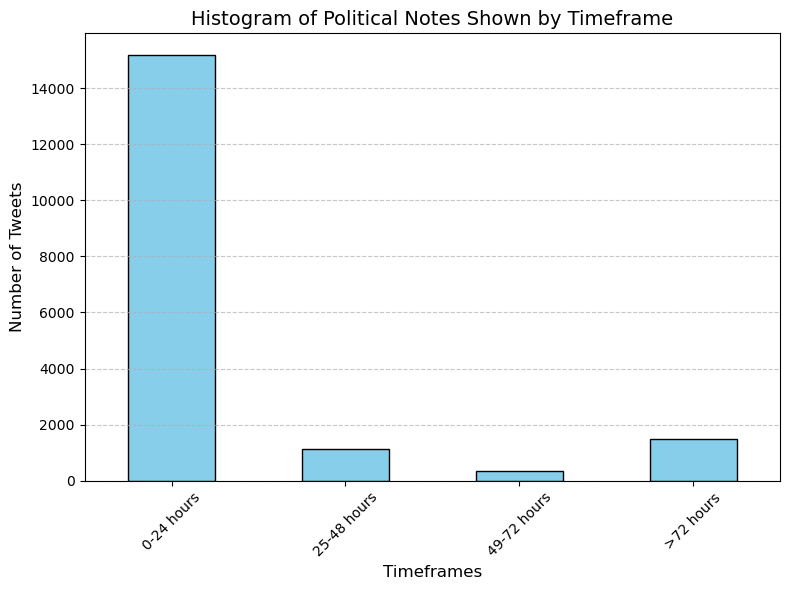

In [383]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]

filtered = tweet_level[(tweet_level['is_political'] == True) & (tweet_level['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

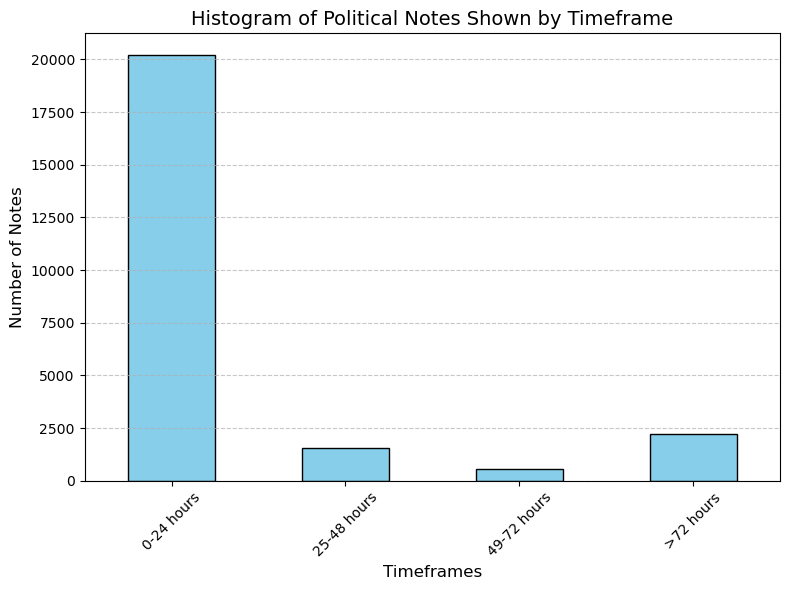

In [381]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]

filtered = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Notes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [497]:
# Note Level:
# random sample of 10 political tweets that get warnings and 10 that didn't get warnings: 
pol_warnings_rand = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 1)].sample(frac=1, random_state=42)
pol_warnings_rand = pol_warnings_rand.head(10)
pol_warnings_rand.to_csv('pol_warnings_rand.csv', index=False)

pol_nowarnings_rand = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 0)].sample(frac=1, random_state=42)
pol_nowarnings_rand = pol_nowarnings_rand.head(10)
pol_nowarnings_rand.to_csv('pol_nowarnings_rand.csv', index=False)

In [123]:
# Tweet Level: (still includes gaza tweets)
# random sample of 10 political tweets that get warnings and 10 that didn't get warnings: 
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    got_shown=('got_shown', 'max') 
)
poltweet_warnings_rand = tweet_level[(tweet_level['is_political'] == True) & (tweet_level['got_shown'] == 1)].sample(frac=1, random_state=33).reset_index()
poltweet_warnings_rand = poltweet_warnings_rand.head(15)
poltweet_warnings_rand.to_csv('poltweet_warnings_rand.csv', index=False)

poltweet_nowarnings_rand = tweet_level[(tweet_level['is_political'] == True) & (tweet_level['got_shown'] == 0)].sample(frac=1, random_state=33).reset_index()
poltweet_nowarnings_rand = poltweet_nowarnings_rand.head(15)
poltweet_nowarnings_rand.to_csv('poltweet_nowarnings_rand.csv', index=False)

In [127]:
#same as above but for non-political:
#tweet level, same of 10 that got warnings and 10 that didn't
tweet_level = df_english.groupby('tweetId').agg(
    is_political = ('is_political', 'first'),
    got_shown = ('got_shown', 'max')
)

nonpoltweet_warning_rand = tweet_level[(tweet_level['is_political'] == False) & (tweet_level['got_shown'] == 1)].sample(frac=1, random_state=33).reset_index()
nonpoltweet_warning_rand = nonpoltweet_warning_rand.head(15)
nonpoltweet_warning_rand.to_csv('nonpoltweet_warning_rand.csv', index=False)

nonpoltweet_nowarning_rand = tweet_level[(tweet_level['is_political'] == False) & (tweet_level['got_shown'] == 0)].sample(frac=1, random_state=33).reset_index()
nonpoltweet_nowarning_rand = nonpoltweet_nowarning_rand.head(15)
nonpoltweet_nowarning_rand.to_csv('nonpoltweet_nowarning_rand.csv', index=False)

In [125]:
# Tweet Level (including gaza)
# random sample of 10 tweets that got warnings and 10 that didn't - not differentiating for is_political
tweet_level = df_english.groupby('tweetId').agg( 
    got_shown=('got_shown', 'max') 
)
tweet_warnings_rand = tweet_level[tweet_level['got_shown'] == 1].sample(frac=1, random_state=33).reset_index()
tweet_warnings_rand = tweet_warnings_rand.head(15)
tweet_warnings_rand.to_csv('tweet_warnings_rand.csv', index=False)

tweet_nowarnings_rand = tweet_level[tweet_level['got_shown'] == 0].sample(frac=1, random_state=33).reset_index()
tweet_nowarnings_rand = tweet_nowarnings_rand.head(15)
tweet_nowarnings_rand.to_csv('tweet_nowarnings_rand.csv', index=False)

In [505]:
# Experimenting with some statistics - looking at relationship between political and got shown:
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'first'),  
    got_shown=('got_shown', 'max') 
)

from scipy.stats import chi2_contingency
import pandas as pd

contingency_table = pd.crosstab(tweet_level['is_political'], tweet_level['got_shown'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Contingency table:")
print(contingency_table)

Chi-square statistic: 523.4299947542369
p-value: 7.591118718962625e-116
Degrees of freedom: 1
Contingency table:
got_shown          0      1
is_political               
False         336696  59699
True          125890  18130


In [509]:
import math

# Calculate odds ratio
odds_political = 18130 / 125890  # odds of getting shown if political
odds_nonpolitical = 59699 / 336696  # odds of getting shown if non-political
odds_ratio = odds_political / odds_nonpolitical
print(f"Odds ratio: {odds_ratio}")

# Calculate phi coefficient
n = 336696 + 59699 + 125890 + 18130
phi = (336696*18130 - 59699*125890) / math.sqrt(396395*144020*396386*77829)
print(f"Phi coefficient: {phi}")

Odds ratio: 0.812227091353254
Phi coefficient: -0.03362682453013057


# More Boilerplate

In [3]:
all_ratings = pd.read_csv("all_ratings.csv")

columns_to_keep = [
    "noteId",
    "agree",
    "disagree",
    "helpfulOther",
    "helpfulClear",
    "helpfulGoodSources",
    "helpfulAddressesClaim",
    "helpfulImportantContext",
    "helpfulUnbiasedLanguage",
    "notHelpfulOther",
    "notHelpfulIncorrect",
    "notHelpfulSourcesMissingOrUnreliable",
    "notHelpfulMissingKeyPoints",
    "notHelpfulHardToUnderstand",
    "notHelpfulArgumentativeOrBiased",
    "notHelpfulSpamHarassmentOrAbuse",
    "notHelpfulIrrelevantSources",
    "notHelpfulOpinionSpeculation",
    "notHelpfulNoteNotNeeded"
]

ratings_filtered = all_ratings[columns_to_keep]

In [5]:
# Note level
# Exploratory Analysis of ratings columns as they relate to is_political notes:

# Get only the necessary columns from df_english
df_filtered = df_english[['noteId', 'got_shown', 'is_political']]

# Define a function to process each column
def analyze_column(column_name):
    # Skip the noteId column since it's used for merging
    if column_name == 'noteId':
        return None
        
    # Create temporary dataframe with just noteId and target column
    temp_df = ratings_filtered[['noteId', column_name]]
    
    # Merge with the got_shown data
    merged_df = df_filtered.merge(temp_df, on='noteId', how='inner')
    
    # Return the groupby result
    return merged_df.groupby('is_political')[column_name].sum()

# Apply to all columns in ratings_filtered
results = {}
for column in ratings_filtered.columns:
    result = analyze_column(column)
    if result is not None:
        results[column] = result

def save_results_with_pandas(results, filename='ratings_helpful_results.csv'):
    # Convert the nested dictionary to a DataFrame
    df = pd.DataFrame.from_dict(results, orient='index')
    
    # Save to CSV
    df.to_csv(filename)
    print(f"Results saved to {filename}")

save_results_with_pandas(results)

Results saved to ratings_helpful_results.csv


In [15]:
ratings_results = pd.read_csv('ratings_helpful_results.csv')

ratings_results['percent_diff'] = (ratings_results['True'] - ratings_results['False'])/ ratings_results['False']
print(ratings_results)

                              Unnamed: 0     False      True  percent_diff
0                                  agree      8689     10140      0.166993
1                               disagree      3463      3689      0.065261
2                           helpfulOther   1666506   1701483      0.020988
3                           helpfulClear  13967280  14660614      0.049640
4                     helpfulGoodSources  10300363  10642835      0.033249
5                  helpfulAddressesClaim  13937320  14754257      0.058615
6                helpfulImportantContext  13893356  14462090      0.040936
7                helpfulUnbiasedLanguage   9238782  10057277      0.088593
8                        notHelpfulOther   1123685   1590422      0.415363
9                    notHelpfulIncorrect   2948563   5169542      0.753241
10  notHelpfulSourcesMissingOrUnreliable   2837528   4514503      0.590999
11            notHelpfulMissingKeyPoints   5454446   8842872      0.621223
12            notHelpfulH

In [167]:
# similar to previous cell, but only counting each unique note once, rather than once for each time it received a rating.
df_filtered = df_english[['noteId', 'got_shown', 'is_political']]

# Define a function to process each column
def analyze_column(column_name):
    # Skip the noteId column since it's used for merging
    if column_name == 'noteId':
        return None
    
    # Create temporary dataframe with just noteId and target column
    temp_df = ratings_filtered[['noteId', column_name]]
    
    # Keep only rows where column_name is 1
    temp_df = temp_df[temp_df[column_name] == 1]
    
    # Drop duplicates to get unique noteIds
    temp_df = temp_df.drop_duplicates(subset=['noteId'])
    
    # Merge with df_filtered
    merged_df = df_filtered.merge(temp_df, on='noteId', how='inner')
    
    # Count unique noteIds per is_political group (sum works since no duplicates)
    return merged_df.groupby('is_political')['noteId'].count()

# Apply to all columns in ratings_filtered
results = {}
for column in ratings_filtered.columns:
    result = analyze_column(column)
    if result is not None:
        results[column] = result

def save_results_with_pandas(results, filename='ratings_results_unique.csv'):
    # Convert the nested dictionary to a DataFrame
    df = pd.DataFrame.from_dict(results, orient='index')
    
    # Save to CSV
    df.to_csv(filename)
    print(f"Results saved to {filename}")

save_results_with_pandas(results)

ratings_results = pd.read_csv('ratings_results_unique.csv')

# Find the % of all political notes that received at least one "1" rating in each category (and same for non-political)
total_pol = df_filtered['is_political'].sum()
total_notpol = (~df_filtered['is_political']).sum()

ratings_results['percentof_political'] = (ratings_results['True']/total_pol)
ratings_results['percentof_notpolitical'] = (ratings_results['False']/total_notpol)

ratings_results.to_csv('ratings_results.csv', index=False)

Results saved to ratings_results_unique.csv


# Gaza

In [69]:
gaza_keywords = [
    'gaza',
    'hamas',
    'israel',
    'hezbollah',
    'october 7',
    'idf',
    'palestinian'
]
def find_keywords(text, gaza_keywords):
    text_lower = str(text).lower()
    found_keywords = [
        keyword for keyword in gaza_keywords 
        if f" {keyword} " in f" {text_lower} "
    ]
    return found_keywords

gaza_keywords_list = []

for text in df['summary']:
    gaza_keywords_list.append(find_keywords(text, gaza_keywords))

df['found_gaza'] = gaza_keywords_list

df['contains_gaza'] = df['found_gaza'].str.len() > 0

# checking a random sample to see if my gaza_tweets is accurate. 7/7 yes (3 deleted tweets)

df_english = df[df['is_english'] == True]
gaza_tweets = df_english[df_english['contains_gaza'] == True].groupby('tweetId').first().reset_index()

gaza_tweets_rand = gaza_tweets.sample(frac=1, random_state=33)

gaza_tweets_rand10 = gaza_tweets_rand.head(10)
gaza_tweets_rand10.to_csv('gaza_tweets_rand10.csv', index=False)

In [93]:
# Repeats script from above after removing notes related to gaza/israel. Comparing to find differences:

# Get only the necessary columns from df_english
df_filtered = df_english[['noteId', 'got_shown', 'is_political', 'contains_gaza']]
df_filtered_nogaza = df_filtered[df_filtered['contains_gaza'] == False]

# Define a function to process each column
def analyze_column(column_name):
    # Skip the noteId column since it's used for merging
    if column_name == 'noteId':
        return None
        
    # Create temporary dataframe with just noteId and target column
    temp_df = ratings_filtered[['noteId', column_name]]
    
    # Merge with the got_shown data
    merged_df = df_filtered_nogaza.merge(temp_df, on='noteId', how='inner')
    
    # Return the groupby result
    return merged_df.groupby('is_political')[column_name].sum()

# Apply to all columns in ratings_filtered
results = {}
for column in ratings_filtered.columns:
    result = analyze_column(column)
    if result is not None:
        results[column] = result

def save_results_with_pandas(results, filename='ratings_results_nogaza.csv'):
    # Convert the nested dictionary to a DataFrame
    df = pd.DataFrame.from_dict(results, orient='index')
    
    # Save to CSV
    df.to_csv(filename)
    print(f"Results saved to {filename}")

save_results_with_pandas(results)

Results saved to ratings_results_nogaza.csv


In [111]:
ratings_results_nogaza = pd.read_csv('ratings_results_nogaza.csv')

ratings_results_nogaza['percent_diff'] = (ratings_results_nogaza['True'] - ratings_results_nogaza['False'])/ ratings_results_nogaza['False']
print(ratings_results_nogaza)

                              Unnamed: 0     False      True  percent_diff
0                                  agree      8675     10058      0.159424
1                               disagree      3460      3648      0.054335
2                           helpfulOther   1643864   1528402     -0.070238
3                           helpfulClear  13781423  13192143     -0.042759
4                     helpfulGoodSources  10145540   9422749     -0.071242
5                  helpfulAddressesClaim  13739058  13210366     -0.038481
6                helpfulImportantContext  13698151  12936015     -0.055638
7                helpfulUnbiasedLanguage   9106118   9012978     -0.010228
8                        notHelpfulOther   1106284   1437831      0.299694
9                    notHelpfulIncorrect   2872392   4448845      0.548829
10  notHelpfulSourcesMissingOrUnreliable   2766206   3872353      0.399879
11            notHelpfulMissingKeyPoints   5356356   7943431      0.482992
12            notHelpfulH

In [105]:
df_gotshown_nogaza = df_english[(df_english['contains_gaza'] == True) & (df_english['got_shown'] == True) & (df_english['is_political'] == True)]
len(df_gotshown_nogaza)

1843

In [109]:
df_gotshown = df_english[(df_english['got_shown'] == True) & (df_english['is_political'] == True)]
len(df_gotshown)

24539

# More Analysis

In [20]:
df_merged.groupby('got_shown').rating_count.median()

got_shown
0    20.0
1    84.0
Name: rating_count, dtype: float64

In [3]:
df_english.groupby('is_political').size()

is_political
False    594344
True     315934
dtype: int64

In [91]:
# Looking to see if a small group of raters submit the majority of the Notes - answer: I don't think so!

series = df.groupby('noteAuthorParticipantId_x').size().sort_values(ascending=False)

# Convert to DataFrame:
author_counts_df = series.reset_index()
author_counts_df.columns = ['noteAuthorParticipantId_x', 'count']
author_counts_df.to_csv('author_counts_df.csv', index=False)

top_100_sum = author_counts_df.head(1000)['count'].sum()

total_sum = author_counts_df['count'].sum()

percentage = (top_100_sum / total_sum) * 100

print(f"Top 100 raters constitute {percentage:.2f}% of the total Notes submitted")

Top 100 raters constitute 21.46% of the total Notes submitted


# Number of Submissions Count

In [188]:
df_english = df[df['is_english'] == True].copy()

In [190]:
# Create function that sums the # of ratings for each is____ keyword list and puts into a dataframe:
submission_summary = []

def count_submissions(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['noteId'].nunique()
        keyword_submission_count = result.loc[True] if True in result.index else 0
        submission_summary.append({'keyword': keyword, 'submission_count': keyword_submission_count})
    else:
        print(f"Column '{col}' not found.")

In [192]:
# enter each keyword list name to call function:
count_submissions('healthsciencecovid')

submission_count = pd.DataFrame(submission_summary)
submission_count.to_csv('submission_count.csv', index=False)

In [85]:
# count total number of unique NoteIds (# of unique submissions)
df_english['noteId'].nunique()

910278

# Number of Tweets count

In [194]:
# Aggregate at the tweetId level (and english-only)
# Must adjust code to include needed columns

df_english = df[df['is_english'] == True]
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    is_scam=('is_scam', 'any'),
    is_health=('is_health', 'any'),
    is_covid=('is_covid', 'any'),
    is_science=('is_science', 'any'),
    is_crypto=('is_crypto', 'any'),
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    is_healthsciencecovid=('is_healthsciencecovid', 'any'),
    noteId=('noteId', lambda x: ','.join(map(str, x.unique())))
)

tweet_summary = []

def count_tweets(keyword):
    col = f'is_{keyword}'
    if col in tweet_level.columns:
        result = tweet_level.groupby(col)['noteId'].nunique()
        keyword_tweet_count = result.loc[True] if True in result.index else 0
        tweet_summary.append({'keyword': keyword, 'tweet_count': keyword_tweet_count})
    else:
        print(f"Column '{col}' not found.")

In [196]:
# enter each keyword list name to call function:
count_tweets('healthsciencecovid')

tweet_count = pd.DataFrame(tweet_summary)
tweet_count.to_csv('tweet_count.csv', index=False)

In [133]:
# count total number of unique tweets (# of unique submissions)
df_english['tweetId'].nunique()

540415

In [156]:
# Create function that plots # of submissions for keyword or keyword list:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

df_english = df[df['is_english']==True]

def plot_keywords_mixed(keywords_dict, search_col='summary'):
    collection_date = pd.Timestamp('2024-11-14')
    last_complete_week = collection_date - datetime.timedelta(days=collection_date.dayofweek + 1)

    # Ensure you're working on a fresh copy to avoid SettingWithCopyWarning
    df = df_english.copy()
    df['created_at'] = pd.to_datetime(df['createdAtMillis_x'], unit='ms')
    df_complete = df[df['created_at'] <= last_complete_week]

    plt.figure(figsize=(20, 10))

    weekly_all = df_complete.set_index('created_at').resample('W').size()
    plt.plot(weekly_all.index, weekly_all.values, lw=2.5, linestyle='--', marker='o',
             label='All Notes', alpha=0.6)

    for keyword, mode in keywords_dict.items():
        if mode == 'column':
            mask = df.get(f'is_{keyword}', pd.Series(False, index=df.index))
        elif mode == 'search':
            mask = df[search_col].str.contains(fr'\b{keyword}\b', case=False, na=False, regex=True)
        else:
            raise ValueError(f"Unknown mode '{mode}' for keyword '{keyword}' (use 'column' or 'search')")

        keyword_notes = df[mask & (df['created_at'] <= last_complete_week)].copy()
        weekly_keyword = keyword_notes.set_index('created_at').resample('W').size()

        plt.plot(weekly_keyword.index, weekly_keyword.values, lw=2.5, marker='o',
                 label=f'{keyword} ({mode})')

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axvline(x=last_complete_week, color='r', linestyle='--', alpha=0.7)
    plt.text(last_complete_week - datetime.timedelta(days=15), plt.ylim()[1]*0.9, 
             'Data collected on Nov 14, 2024', 
             rotation=90, verticalalignment='top', color='red')

    plt.title('Community Notes Submissions', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Submissions', fontsize=12)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

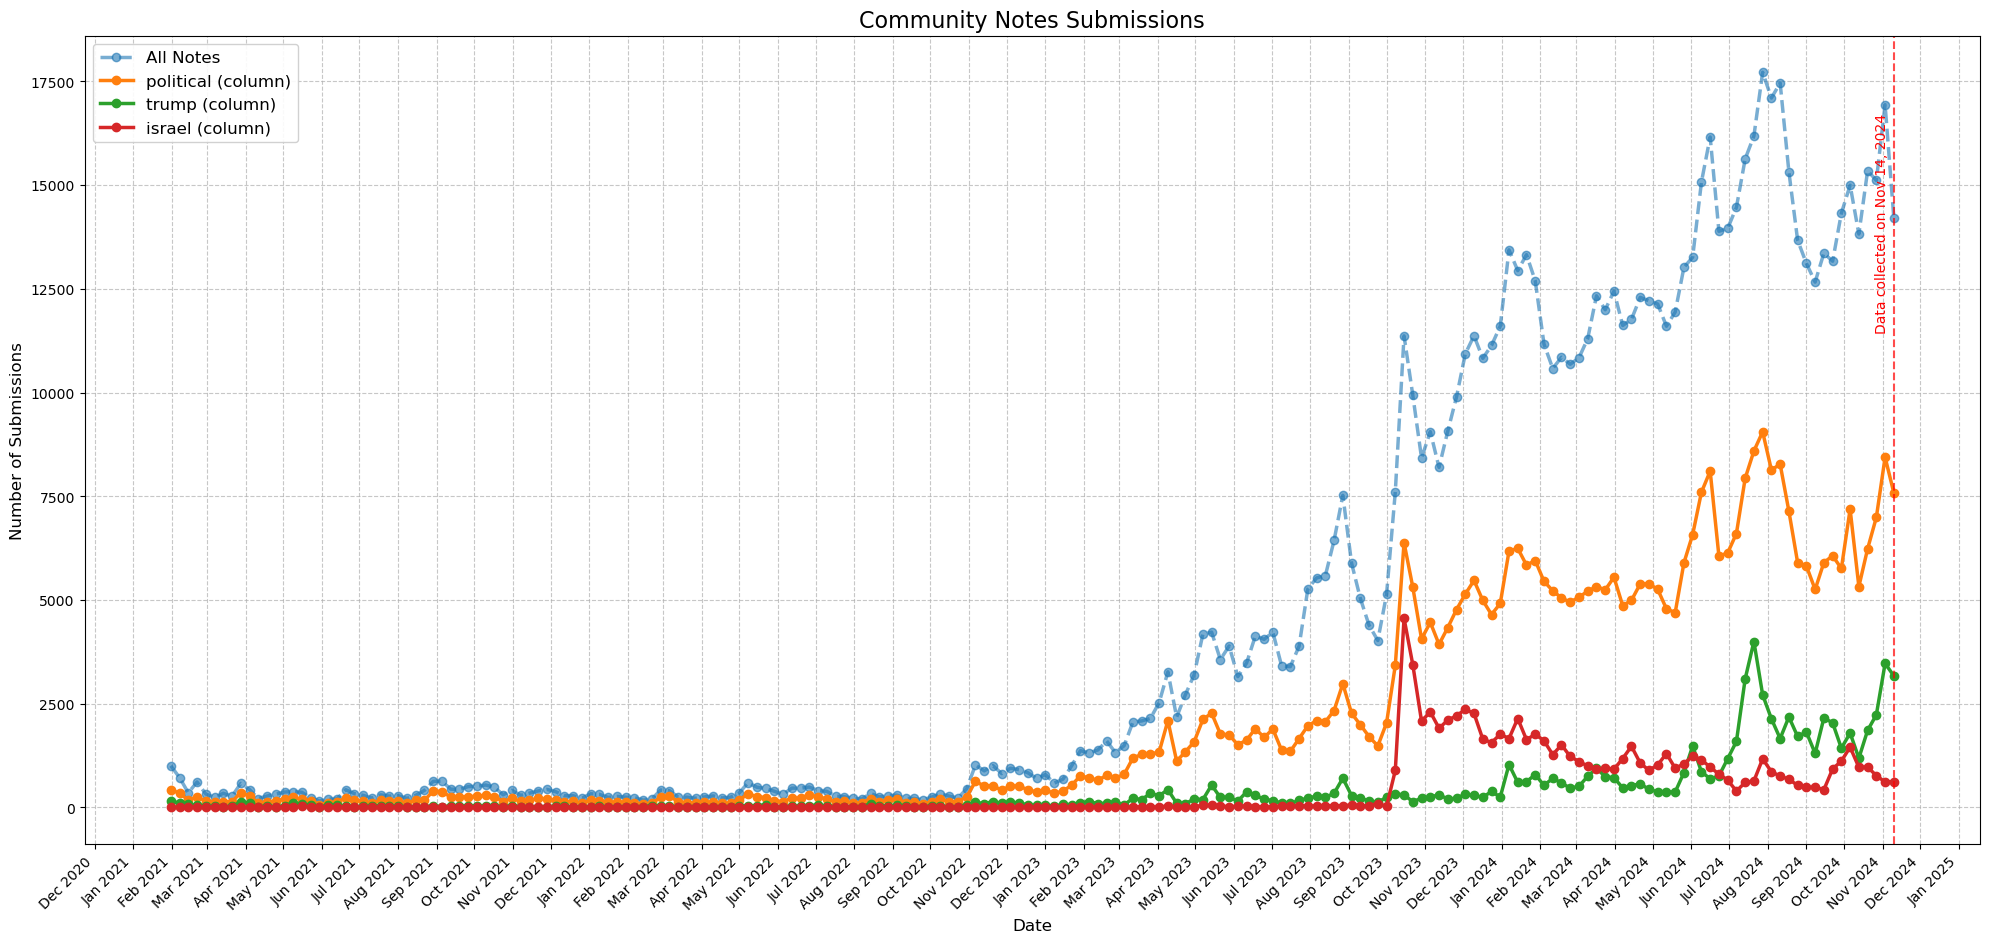

In [158]:
plot_keywords_mixed({
    'political': 'column',
    'trump': 'column',
    'israel': 'column'
})

# Ratings Count

In [14]:
# preprocessing ratings to use in the next cell

all_ratings = pd.read_csv("all_ratings.csv", usecols=['noteId'])
ratings_count = all_ratings['noteId'].value_counts().reset_index()
ratings_count.columns = ['noteId', 'rating_count']

In [198]:
df_english = df[df['is_english'] == True].copy()
df_english = df_english.merge(ratings_count, on='noteId', how='left')

In [200]:
# Create function that sums the # of ratings for each is____ keyword list and puts into a dataframe:
rating_summary = []

def count_ratings(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['rating_count'].sum()
        keyword_rating_count = result.loc[True] if True in result.index else 0
        rating_summary.append({'keyword': keyword, 'rating_count': keyword_rating_count})
    else:
        print(f"Column '{col}' not found.")

In [202]:
count_ratings('healthsciencecovid')

ratings_df = pd.DataFrame(rating_summary)
ratings_df.to_csv('ratings_count.csv', index=False)

In [69]:
df_english['rating_count'].sum()

73365225.0

In [211]:
# creates a function that plots # of ratings for given keywords:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

def plot_filtered_note_counts(df, ratings_count, keywords_dict, search_col='summary'):
    collection_date = pd.Timestamp('2024-11-14')
    last_complete_week = collection_date - datetime.timedelta(days=collection_date.dayofweek + 1)

    df_english = df[df['is_english'] == True].copy()
    df_english['created_at'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')
    df_english = df_english[df_english['created_at'] <= last_complete_week]

    df_english = df_english.merge(ratings_count, on='noteId', how='left')
    df_english['rating_count'] = df_english['rating_count'].fillna(0).astype(int)

    # Plot all notes
    plt.figure(figsize=(20, 10))
    weekly_all = df_english.resample('W', on='created_at')['rating_count'].sum()
    plt.plot(weekly_all.index, weekly_all.values, lw=2.5, linestyle='--', marker='o',
             label='All Notes', alpha=0.6)

    for keyword, mode in keywords_dict.items():
        if mode == 'column':
            mask = df_english.get(f'is_{keyword}', pd.Series(False, index=df_english.index))

        elif mode == 'search':
            mask = df_english[search_col].str.contains(fr'\b{keyword}\b', case=False, na=False, regex=True)

        elif mode == 'custom':
            if keyword == 'non_political':
                mask = ~df_english.get('is_political', pd.Series(False, index=df_english.index))
            else:
                raise ValueError(f"Custom mode not implemented for keyword '{keyword}'")

        else:
            raise ValueError(f"Unknown mode '{mode}' for keyword '{keyword}' (use 'column', 'search', or 'custom')")

        keyword_df = df_english[mask].copy()
        weekly_ratings = keyword_df.resample('W', on='created_at')['rating_count'].sum()

        plt.plot(weekly_ratings.index, weekly_ratings.values, lw=2.5, marker='o',
                 label=f'{keyword} ({mode})')

    # Plot formatting
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axvline(x=last_complete_week, color='r', linestyle='--', alpha=0.7)
    plt.text(last_complete_week - datetime.timedelta(days=15), plt.ylim()[1]*0.9, 
             'Data collected on Nov 14, 2024', 
             rotation=90, verticalalignment='top', color='red')
    plt.title('Community Notes Ratings', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Ratings', fontsize=12)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()


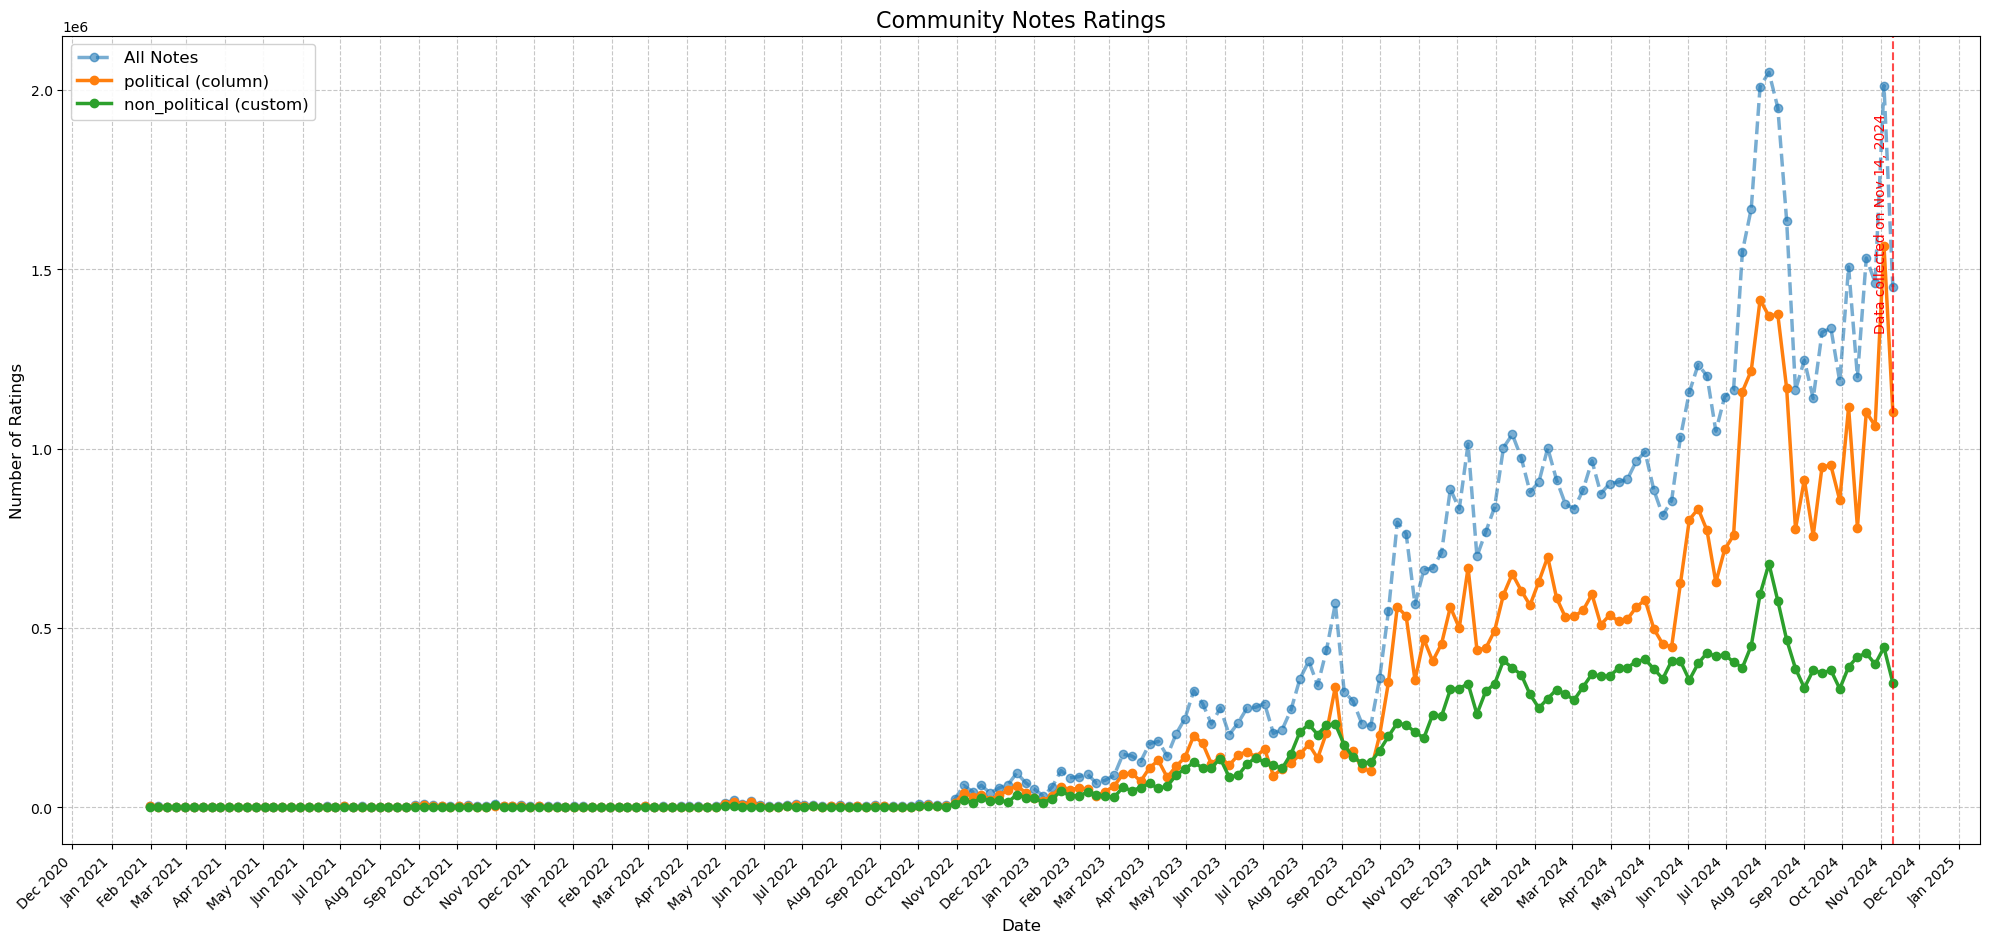

In [213]:
keywords_dict = {
    'political': 'column',
    'non_political': 'custom'
}

plot_filtered_note_counts(df, ratings_count, keywords_dict)

In [ ]:
keywords_dict = {     
    'isnotpolitical': 'column',
    'political': 'column'
}

plot_filtered_note_counts(df, ratings_count, keywords_dict)

# Tableau experiments

In [315]:
# creating file to then export to Tableau for visualization:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

# Create proper copies
all_notes = df_english.copy()
political_notes = df_english[df_english['is_political'] == True].copy()
df['is_obama'] = df['summary'].str.contains(fr'\bobama\b', case=False, na=False, regex=True)
obama_notes = df[(df['is_english'] == True) & (df['is_obama'] == True)].copy()
df['is_trump'] = df['summary'].str.contains(fr'\btrump\b', case=False, na=False, regex=True)
trump_notes = df[(df['is_english'] == True) & (df['is_trump'] == True)].copy()
df['is_harris'] = df['summary'].str.contains(fr'\bharris\b', case=False, na=False, regex=True)
harris_notes = df[(df['is_english'] == True) & (df['is_harris'] == True)].copy()
df['is_israel'] = df['summary'].str.contains(fr'\bisrael\b', case=False, na=False, regex=True)
israel_notes = df[(df['is_english'] == True) & (df['is_israel'] == True)].copy()

# Convert timestamps to datetime for both datasets
political_notes['created_at'] = pd.to_datetime(political_notes['createdAtMillis_x'], unit='ms')
all_notes['created_at'] = pd.to_datetime(all_notes['createdAtMillis_x'], unit='ms')
obama_notes['created_at'] = pd.to_datetime(obama_notes['createdAtMillis_x'], unit='ms')
trump_notes['created_at'] = pd.to_datetime(trump_notes['createdAtMillis_x'], unit='ms')
harris_notes['created_at'] = pd.to_datetime(harris_notes['createdAtMillis_x'], unit='ms')
israel_notes['created_at'] = pd.to_datetime(israel_notes['createdAtMillis_x'], unit='ms')

# Get the date of data collection
collection_date = pd.Timestamp('2024-11-14')

# Calculate the last complete week
last_complete_week = collection_date - datetime.timedelta(days=collection_date.dayofweek + 1)

# Filter for complete data periods
political_notes_complete = political_notes[political_notes['created_at'] <= last_complete_week].copy()
all_notes_complete = all_notes[all_notes['created_at'] <= last_complete_week].copy()
obama_notes_complete = obama_notes[obama_notes['created_at'] <= last_complete_week].copy()
trump_notes_complete = trump_notes[trump_notes['created_at'] <= last_complete_week].copy()
harris_notes_complete = harris_notes[harris_notes['created_at'] <= last_complete_week].copy()
israel_notes_complete = israel_notes[israel_notes['created_at'] <= last_complete_week].copy()

# combine df's and export for use in Tableau:
political_notes_complete['Category'] = 'Political'
all_notes_complete['Category'] = 'All Notes'
obama_notes_complete['Category'] = 'Obama'
trump_notes_complete['Category'] = 'Trump'
harris_notes_complete['Category'] = 'Harris'
israel_notes_complete['Category'] = 'Israel'
combined_data = pd.concat([political_notes_complete, all_notes_complete, obama_notes_complete, trump_notes_complete, harris_notes_complete, israel_notes_complete])
combined_data.to_csv('combined_data.csv', index=False)

# Counting Keywords, Bigrams

In [247]:
# Now I want to find out what the most common words in the "summary" column are for specific date range:
from collections import Counter
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from datetime import datetime

# Convert milliseconds timestamp to datetime
df_english.loc[:, 'created_date'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')

start_date = pd.Timestamp('2020-12-31')
end_date = pd.Timestamp('2024-11-06')  
   

# Create filtered dataframe with entries between the start and end dates
df_filtered = df_english[(df_english['created_date'] >= start_date) & 
                         (df_english['created_date'] <= end_date)]

# Download stopwords if you haven't already
nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Assuming df_english is already loaded
# Step 1: Combine all text from the summary column
all_text = ' '.join(df_filtered['summary'].dropna().astype(str))

# Step 2: Convert to lowercase and split into words
# Using regex to keep only alphanumeric characters
words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

# Step 3: Filter out stopwords
filtered_words = [word for word in words if word not in stop_words]

# Step 4: Count word frequencies
word_counts = Counter(filtered_words)

# Step 5: Create a DataFrame of word frequencies
word_freq_df = pd.DataFrame({
    'word': list(word_counts.keys()),
    'frequency': list(word_counts.values())
})

# Step 6: Sort by frequency in descending order
word_freq_df_range = word_freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

word_freq_df_range.to_csv('word_freq_df_range.csv', index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ryanmurtfeldt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [233]:
# counting bigrams (2 word phrases) in 'summary' corpus:

from collections import Counter
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.util import bigrams
from datetime import datetime

df_english.loc[:, 'created_date'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')

start_date = pd.Timestamp('2020-12-31')
end_date = pd.Timestamp('2024-11-06')

df_filtered = df_english[(df_english['created_date'] >= start_date) & 
                         (df_english['created_date'] <= end_date)]

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

all_text = ' '.join(df_filtered['summary'].dropna().astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

filtered_words = [word for word in words if word not in stop_words]

bigrams_list = list(bigrams(filtered_words))

bigram_counts = Counter(bigrams_list)

bigram_freq_df = pd.DataFrame({
    'bigram': [' '.join(bigram) for bigram in bigram_counts.keys()],
    'frequency': list(bigram_counts.values())
})

bigram_freq_df_range = bigram_freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ryanmurtfeldt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [243]:
bigram_freq_df_range.to_csv('bigrams_count.csv', index=False)

In [245]:
from collections import Counter
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.util import trigrams
from datetime import datetime

# Convert milliseconds timestamp to datetime
df_english.loc[:, 'created_date'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')

# Define date range
start_date = pd.Timestamp('2020-12-31')
end_date = pd.Timestamp('2024-11-06')

# Filter the dataframe by date
df_filtered = df_english[(df_english['created_date'] >= start_date) & 
                         (df_english['created_date'] <= end_date)]

# Download stopwords if needed
nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Combine all text from the summary column
all_text = ' '.join(df_filtered['summary'].dropna().astype(str))

# Convert to lowercase and extract words
words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

# Filter out stopwords
filtered_words = [word for word in words if word not in stop_words]

# Generate trigrams
trigrams_list = list(trigrams(filtered_words))

# Count trigram frequencies
trigram_counts = Counter(trigrams_list)

# Create a DataFrame of trigram frequencies
trigram_freq_df = pd.DataFrame({
    'trigram': [' '.join(trigram) for trigram in trigram_counts.keys()],
    'frequency': list(trigram_counts.values())
})

# Sort by frequency in descending order
trigram_freq_df_range = trigram_freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

# Save to CSV
trigram_freq_df_range.to_csv('trigram_count.csv', index=False)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ryanmurtfeldt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# SQL experiments

In [73]:
import sqlite3
conn = sqlite3.connect("community_notes.db")
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS notes")
cursor.execute("DROP TABLE IF EXISTS analysis")
conn.commit()

# create tables (notes and analysis)
cursor.execute('''CREATE TABLE IF NOT EXISTS notes (
noteId INTEGER PRIMARY KEY,
tweetId INTEGER,
noteAuthorParticipantId_x TEXT, 
summary TEXT,
is_english INTEGER,
createdAtMillis_x INTEGER,
timestampMillisOfFirstNonNMRStatus INTEGER,
FOREIGN KEY (tweetId) REFERENCES analysis(tweetId)
)''')

cursor.execute('''CREATE TABLE IF NOT EXISTS analysis (
tweetId INTEGER PRIMARY KEY,
is_english INTEGER,
noteId INTEGER,
isnot_political INTEGER,
is_political INTEGER,
got_shown INTEGER, 
hours_to_show DECIMAL,
FOREIGN KEY (noteId) REFERENCES notes(noteId)
)''')
    
conn.commit()

# load data from pandas df
# Remove duplicates based on noteId before insertion
df = df.drop_duplicates(subset=['noteId'])
df = df.drop_duplicates(subset=['tweetId'])
df["noteId"] = df["noteId"].fillna(-1).astype(int)
df["tweetId"] = df["tweetId"].fillna(-1).astype(int)

# Only insert specific columns into the database
columns_to_use_notes = ['noteId', 'tweetId', 'noteAuthorParticipantId_x', 'summary', 
                  'is_english', 'createdAtMillis_x', 'timestampMillisOfFirstNonNMRStatus']
columns_to_use_analysis = ['tweetId', 'is_english', 'noteId', 'isnot_political', 'is_political', 'got_shown', 'hours_to_show']
df[columns_to_use_notes].to_sql("notes", conn, if_exists="append", index=False)
df[columns_to_use_analysis].to_sql("analysis", conn, if_exists="append", index=False)

864937

In [77]:
pd.read_sql("PRAGMA table_info(notes);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,noteId,INTEGER,0,None,1
1,1,tweetId,INTEGER,0,None,0
2,2,noteAuthorParticipantId_x,TEXT,0,None,0
3,3,summary,TEXT,0,None,0
4,4,is_english,INTEGER,0,None,0
5,5,createdAtMillis_x,INTEGER,0,None,0
6,6,timestampMillisOfFirstNonNMRStatus,INTEGER,0,None,0


In [87]:
pd.read_sql("SELECT * FROM analysis LIMIT 6;", conn)

,tweetId,is_english,noteId,isnot_political,is_political,got_shown,hours_to_show
0,-1,0,1352796878438424576,1,0,0,None
1,20,0,1784819259433955752,1,0,0,None
2,560712682,1,1716678007056683276,1,0,0,None
3,1316941803,1,1767686040930656621,1,0,0,None
4,1552417367,0,1712346008217158028,1,0,0,None
5,1720773846,1,1772810912295981082,1,0,0,None


In [93]:
pd.read_sql("SELECT COUNT(*) AS analysis_count FROM analysis;", conn)

,analysis_count
0,864937


In [99]:
pd.read_sql("SELECT * FROM analysis WHERE got_shown = 1 LIMIT 4;", conn)

,tweetId,is_english,noteId,isnot_political,is_political,got_shown,hours_to_show
0,4363663251087361,1,1838244061498503195,1,0,1,39.830241
1,253611215190896642,1,1543807252531974146,1,0,1,590.961504
2,674717899802591232,1,1593757183333875713,0,1,1,11.672711
3,708304955149451264,0,1776241817786232835,1,0,1,6.716927


In [101]:
pd.read_sql("SELECT AVG(hours_to_show) AS avg_hours FROM analysis WHERE hours_to_show IS NOT NULL;", conn)

,avg_hours
0,42.606124


In [103]:
pd.read_sql("SELECT got_shown, COUNT(*) AS count FROM analysis GROUP BY got_shown;", conn)

,got_shown,count
0,0,758870
1,1,106067


In [105]:
# Join notes and analysis tables
pd.read_sql("""
SELECT n.noteId, n.summary, a.is_political, a.got_shown
FROM notes n
JOIN analysis a ON n.noteId = a.noteId
LIMIT 10;
""", conn)

,noteId,summary,is_political,got_shown
0,1352796878438424576,None,0,0
1,1784819259433955752,X. x.com,0,0
2,1716678007056683276,This tweet is from 2008 https://www.reuters...,0,0
3,1767686040930656621,"Considering Sony themselves tweeted it, it was...",0,0
4,1712346008217158028,"Na verdade, o site só para homens já chegou. T...",0,0
5,1772810912295981082,WARNING This is not the real X account of Tay...,0,0
6,1817639812435955833,A Liga Internacional de Pa-Kua foi inventada n...,0,0
7,1444410721966727173,"For those wondering what this tweet is about, ...",0,0
8,1809946047680291171,このツイートは2010年6月15日に2010 FIFAワールドカップ日本対カメルーン戦に向け...,0,0
9,1775599227957071963,イランでは、2009年にアンタルヤ行きの直行便が禁止されました。しかし、アンタルヤ行きの需要...,0,0


# Preprocessing: Cells to Skip for Now - see below:

In [ ]:
# Use to move columns around as needed

columns = df.columns.tolist()  
is_political_index = columns.index('is_political')  

new_position = max(0, is_political_index - 2)

columns.insert(new_position, columns.pop(is_political_index))
df = df[columns]

In [ ]:
# read in each notes_ratings file

import pandas as pd

notes_ratings0 = pd.read_csv('~/Downloads/ratings-00000.tsv', sep='\t')
notes_ratings1 = pd.read_csv('~/Downloads/ratings-00001.tsv', sep='\t')
notes_ratings2 = pd.read_csv('~/Downloads/ratings-00002.tsv', sep='\t')
notes_ratings3 = pd.read_csv('~/Downloads/ratings-00003.tsv', sep='\t')
notes_ratings4 = pd.read_csv('~/Downloads/ratings-00004.tsv', sep='\t')
notes_ratings5 = pd.read_csv('~/Downloads/ratings-00005.tsv', sep='\t')
notes_ratings6 = pd.read_csv('~/Downloads/ratings-00006.tsv', sep='\t')
notes_ratings7 = pd.read_csv('~/Downloads/ratings-00007.tsv', sep='\t')
notes_ratings8 = pd.read_csv('~/Downloads/ratings-00008.tsv', sep='\t')
notes_ratings9 = pd.read_csv('~/Downloads/ratings-00009.tsv', sep='\t')
notes_ratings10 = pd.read_csv('~/Downloads/ratings-00010.tsv', sep='\t')
notes_ratings11 = pd.read_csv('~/Downloads/ratings-00011.tsv', sep='\t')
notes_ratings12 = pd.read_csv('~/Downloads/ratings-00012.tsv', sep='\t')
notes_ratings13 = pd.read_csv('~/Downloads/ratings-00013.tsv', sep='\t')
notes_ratings14 = pd.read_csv('~/Downloads/ratings-00014.tsv', sep='\t')
notes_ratings15 = pd.read_csv('~/Downloads/ratings-00015.tsv', sep='\t')

In [ ]:
# This didn't work - still too big for my RAM
# Loop through the notes_ratings one at a time; later once I know which notes ratings I want to look at and use.
# pre-process to make smaller (remove columns not needed); merge into single csv
notes_ratings_list = [notes_ratings0, notes_ratings1, notes_ratings2, notes_ratings3, notes_ratings4, notes_ratings5, notes_ratings6, notes_ratings7, notes_ratings8, notes_ratings9, notes_ratings10, notes_ratings11, notes_ratings12, notes_ratings13, notes_ratings14, notes_ratings15]

# dropping columns from Notes_Ratings I don't need
# Initialize an empty dictionary to store the processed DataFrames
processed_files = {}

# Loop through the files and process them
for i, file in enumerate(notes_ratings_list):
    # Define columns to drop
    columns = "helpful, notHelpful, helpfulInformative, helpfulEmpathetic, helpfulUniqueContext, notHelpfulOpinionSpeculationOrBias, notHelpfulOutdated, notHelpfulOffTopic"
    quoted_columns = [col.strip() for col in columns.split(",")]
    
    # Process the file
    notes_ratings_clean = file.drop(columns=quoted_columns, errors='ignore')
    notes_ratings_clean = notes_ratings_clean.astype(str)
    
    # Save the processed DataFrame in the dictionary with a unique key
    processed_files[f'file_{i}'] = notes_ratings_clean

In [ ]:
# skip for now
# read in userEnrollment file when/if needed
import pandas as pd

enrollment = pd.read_csv('~/Downloads/userEnrollment-00000.tsv', sep='\t')

In [ ]:
### Old bits of code:

In [ ]:
## Old code using a regular expression...but Field encouraged me to change to a simpler substring search (which I did above)
# Check for keywords in "summary" column (text of Notes) using a regexp

import re

# ensure all objects in summary column are strings
df['summary'] = df['summary'].astype(str)

# uses a regular expression to search for each keyword in the "summary" text
def find_keywords(text, keywords):
    found_keywords = [
        keyword for keyword in keywords 
        if re.search(rf'\b{re.escape(keyword)}\b', str(text), re.IGNORECASE)
    ]
    return found_keywords